<a href="https://colab.research.google.com/github/Ganasa18/belajar-tensorflow/blob/main/train_class_prompt_labeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# GOOGLE DRIVE PERSISTENT STORAGE SETUP
# TARUH DI PALING ATAS NOTEBOOK
# =========================================================

from google.colab import drive
import os
import shutil

# 1. Mount Google Drive
drive.mount("/content/drive")

# 2. Folder permanen untuk project router
SAVE_DIR = "/content/drive/MyDrive/router_classifier"
os.makedirs(SAVE_DIR, exist_ok=True)

print("SAVE_DIR:", SAVE_DIR)


# =========================================================
# FILE PATHS - PERSISTENT
# =========================================================

BASE_PATH = f"{SAVE_DIR}/router_teacher_checkpoint.csv"
EXTRA_ALL_PATH = f"{SAVE_DIR}/router_teacher_extra_all.csv"

CURRENT_DATASET_PATH = (
    f"{SAVE_DIR}/router_dataset_current.csv"
)

CURRENT_MODEL_PATH = (
    f"{SAVE_DIR}/router_classifier_current.joblib"
)

ROUND_LOG_PATH = (
    f"{SAVE_DIR}/router_tuning_rounds.csv"
)


# =========================================================
# MIGRATE FILE LAMA DARI /content
# HANYA COPY JIKA FILE DRIVE BELUM ADA
# =========================================================

migration_files = {
    "/content/router_teacher_checkpoint.csv":
        BASE_PATH,

    "/content/router_teacher_extra_all.csv":
        EXTRA_ALL_PATH,

    "/content/router_dataset_current.csv":
        CURRENT_DATASET_PATH,

    "/content/router_classifier_current.joblib":
        CURRENT_MODEL_PATH,

    "/content/router_tuning_rounds.csv":
        ROUND_LOG_PATH,
}


print("\nChecking old files...")

for old_path, new_path in migration_files.items():

    if os.path.exists(old_path):

        if not os.path.exists(new_path):

            shutil.copy2(
                old_path,
                new_path
            )

            print(
                "COPIED:",
                old_path,
                "->",
                new_path
            )

        else:

            print(
                "SKIP existing:",
                new_path
            )

    else:

        print(
            "Old file not found:",
            old_path
        )


# =========================================================
# CHECK SAVED STATE
# =========================================================

print("\n" + "=" * 60)
print("PERSISTENT STORAGE STATUS")
print("=" * 60)

paths = {
    "BASE": BASE_PATH,
    "EXTRA": EXTRA_ALL_PATH,
    "DATASET": CURRENT_DATASET_PATH,
    "MODEL": CURRENT_MODEL_PATH,
    "ROUND LOG": ROUND_LOG_PATH,
}

for name, path in paths.items():

    if os.path.exists(path):

        size_mb = (
            os.path.getsize(path)
            / 1024
            / 1024
        )

        print(
            f"{name:10} OK "
            f"{size_mb:.2f} MB"
        )

    else:

        print(
            f"{name:10} belum ada"
        )


print("\nGoogle Drive persistent setup selesai.")

In [1]:
# 1. Install library
!pip install -q datasets pandas requests tqdm scikit-learn sentence-transformers joblib

In [2]:
# 2. Download dataset Indonesia

from datasets import load_dataset

ds = load_dataset(
    "ilhamfadheel/alpaca-cleaned-indonesian",
    split="train"
)

print(ds)
print(ds[0])

README.md:   0%|          | 0.00/10.0k [00:00<?, ?B/s]

AlpacaCleaned_translated_id.json: reconstructing file:   0%|          |  0.00B / 35.3MB            

AlpacaCleaned_translated_id.json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45631 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 45631
})
{'instruction': 'Sebutkan tiga senyawa organik.', 'input': '', 'output': 'Tiga senyawa organik adalah glukosa (C6H12O6), metana (CH4), dan etanol (C2H5OH).'}


In [3]:
# # Ambil 5.000 prompt dulu
# SAMPLE_SIZE = 5000

# ds_small = ds.shuffle(seed=42).select(
#     range(min(SAMPLE_SIZE, len(ds)))
# )

# def build_prompt(row):
#     instruction = row["instruction"].strip()
#     input_text = row["input"].strip()

#     if input_text:
#         return instruction + "\n" + input_text

#     return instruction

# prompts = [build_prompt(x) for x in ds_small]

# print("Jumlah prompt:", len(prompts))

# for x in prompts[:5]:
#     print("\n---")
#     print(x)

Jumlah prompt: 5000

---
Beri saya pertanyaan untuk ditanyakan kepada seseorang yang Anda kenal.

---
Jelaskan faktor-faktor yang berkontribusi terhadap krisis ekonomi global saat ini.

---
Jelaskan seperti apa hari-hari musim panas pada umumnya di gurun.

---
Tulis ulang kalimat berikut untuk mendapatkan arti yang berbeda: "Saya memakan apelnya."

---
Tuliskan sebuah cerita tentang seorang wanita yang bertahan melewati kesulitan.


In [4]:
# 4. Buat label router SIMPLE
# Fakta sederhana, lookup, klasifikasi sederhana,
# jawaban singkat, operasi mudah.

# GENERAL
# Penjelasan umum yang tidak membutuhkan reasoning berat.

# REASONING
# Analisis, matematika, planning, comparison,
# trade-off, deduksi, multi-step problem.

# CODING_SIMPLE
# Generate snippet sederhana, regex, SQL sederhana,
# fungsi kecil, syntax.

# CODING_COMPLEX
# Debugging kompleks, architecture, multi-file,
# race condition, performance, security review.

# TRANSFORM
# Translation, summarization, rewrite,
# extract, shorten, formatting.

# CREATIVE
# Story, brainstorming kreatif, slogan,
# dialog, ide kreatif.

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE"
]

In [5]:
# 5. Konfigurasi API teacher
import os

BASE_URL = "https://openrouter.ai/api/v1/chat/completions"
API_KEY = "ISI_API_KEY"
MODEL = "openrouter/free"

TEMPERATURE = 0
TIMEOUT = 90

In [7]:
from google.colab import userdata
API_KEY = userdata.get('OPEN_ROUTER')

In [8]:
# 6. Teacher prompt
SYSTEM_PROMPT = """
You are labeling user prompts for an AI model router.

Classify each prompt into EXACTLY ONE label:

SIMPLE
- Simple factual questions
- Easy lookup
- Basic classification
- Very short/simple task
- Does not require substantial reasoning

GENERAL
- General explanation
- Normal knowledge question
- Moderate general assistant task
- Does not clearly belong to another category

REASONING
- Mathematics
- Multi-step reasoning
- Planning
- Comparison and trade-offs
- Analysis
- Deduction
- Complex decision making

CODING_SIMPLE
- Small code snippets
- Simple functions
- Regex
- Basic SQL
- Syntax questions
- Straightforward programming tasks

CODING_COMPLEX
- Complex debugging
- Software architecture
- Multi-component systems
- Race conditions
- Security/code review
- Performance optimization
- Complex implementation

TRANSFORM
- Translation
- Summarization
- Rewrite
- Shortening
- Extraction
- Reformatting
- Changing an existing text without requiring substantial new reasoning

CREATIVE
- Story writing
- Creative brainstorming
- Dialogue
- Slogans
- Fiction
- Creative ideation

Important rules:

1. Classify based on USER INTENT, not individual keywords.
2. The prompt may be Indonesian, English, or mixed Indonesian-English.
3. Technical words do NOT automatically mean CODING.
4. Mentioning a language such as "Bahasa Inggris" does NOT automatically mean TRANSFORM.
5. "Explain" does NOT automatically mean REASONING.
6. Choose CODING_COMPLEX only if strong technical reasoning or debugging is actually required.
7. Use SIMPLE for genuinely easy tasks.
8. Return valid JSON only.

Output schema:

{
  "label": "ONE_LABEL",
  "difficulty": 1,
  "confidence": 0.95
}

difficulty must be integer 1-5.
confidence must be number 0-1.
"""

In [13]:
# 7. Fungsi call API
import requests
import time

def call_teacher(prompt):
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    }

    payload = {
        "model": MODEL,
        "temperature": 0,
        "messages": [
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": prompt
            }
        ]
    }

    print("  -> POST", BASE_URL)
    print("  -> model:", MODEL)

    start = time.time()

    response = requests.post(
        BASE_URL,
        headers=headers,
        json=payload,

        # jangan 90 detik dulu untuk debugging
        timeout=(10, 30)
    )

    print(
        f"  <- HTTP {response.status_code}"
        f" ({time.time() - start:.2f}s)"
    )

    response.raise_for_status()

    data = response.json()

    return data["choices"][0]["message"]["content"]

In [22]:
# 8. Parser JSON yang lebih tahan error

import re

def parse_teacher_output(text):
    text = text.strip()

    match = re.search(r'\{[\s\S]*?\}', text)

    if not match:
        raise ValueError(
            f"Tidak menemukan JSON: {text[:300]}"
        )

    data = json.loads(match.group())

    label = data.get("label")
    difficulty = int(data.get("difficulty"))
    confidence = float(data.get("confidence"))

    if label not in LABELS:
        raise ValueError(f"Label invalid: {label}")

    if not 1 <= difficulty <= 5:
        raise ValueError("Difficulty invalid")

    if not 0 <= confidence <= 1:
        raise ValueError("Confidence invalid")

    return {
        "label": label,
        "difficulty": difficulty,
        "confidence": confidence
    }

In [15]:
# 9. Tes 1 prompt dulu

test_prompt = """
review architecture backend saya dan cari kemungkinan
race condition serta bottleneck performance
"""

raw = call_teacher(test_prompt)

print("RAW:")
print(raw)

parsed = parse_teacher_output(raw)

print("\nPARSED:")
print(parsed)

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.65s)
RAW:
{
  "label": "CODING_COMPLEX",
  "difficulty": 4,
  "confidence": 0.92
}

PARSED:
{'label': 'CODING_COMPLEX', 'difficulty': 4, 'confidence': 0.92}


In [23]:
# 11. Teacher labeling + checkpoint
import pandas as pd
import os

CHECKPOINT_PATH = "/content/router_teacher_checkpoint.csv"

if os.path.exists(CHECKPOINT_PATH):
    df_result = pd.read_csv(CHECKPOINT_PATH)

    print(
        "Resume checkpoint:",
        len(df_result),
        "prompt"
    )

else:
    df_result = pd.DataFrame(
        columns=[
            "prompt",
            "label",
            "difficulty",
            "confidence",
            "status"
        ]
    )

    print("Checkpoint belum ada, mulai dari 0")

print(df_result.head())
print("Rows:", len(df_result))

Resume checkpoint: 40 prompt
                                              prompt      label  difficulty  \
0  Beri saya pertanyaan untuk ditanyakan kepada s...     SIMPLE           1   
1  Jelaskan faktor-faktor yang berkontribusi terh...    GENERAL           3   
2  Jelaskan seperti apa hari-hari musim panas pad...     SIMPLE           1   
3  Tulis ulang kalimat berikut untuk mendapatkan ...  TRANSFORM           1   
4  Tuliskan sebuah cerita tentang seorang wanita ...   CREATIVE           3   

   confidence status  
0        0.95     ok  
1        0.93     ok  
2        0.95     ok  
3        0.95     ok  
4        0.95     ok  
Rows: 40


In [26]:
# #12. Loop labeling DEPRECTATED FLOW

# from tqdm.auto import tqdm
# import time

# START_INDEX = len(df_result)

# SAVE_EVERY = 20
# MAX_RETRIES = 3

# results = df_result.to_dict("records")

# print("Mulai dari index:", START_INDEX)
# print("Total prompt:", len(prompts))

# for i in tqdm(
#     range(START_INDEX, len(prompts)),
#     initial=START_INDEX,
#     total=len(prompts)
# ):

#     prompt = prompts[i]
#     success = False

#     for attempt in range(MAX_RETRIES):
#         try:
#             raw = call_teacher(prompt)
#             parsed = parse_teacher_output(raw)

#             results.append({
#                 "prompt": prompt,
#                 "label": parsed["label"],
#                 "difficulty": parsed["difficulty"],
#                 "confidence": parsed["confidence"],
#                 "status": "ok"
#             })

#             success = True
#             break

#         except Exception as e:
#             print(
#                 f"\nError index {i}, "
#                 f"attempt {attempt + 1}/{MAX_RETRIES}: "
#                 f"{type(e).__name__}: {e}"
#             )

#             try:
#                 print("RAW RESPONSE:", raw[:500])
#             except:
#                 pass

#         time.sleep(2 * (attempt + 1))

#     if not success:
#         results.append({
#             "prompt": prompt,
#             "label": None,
#             "difficulty": None,
#             "confidence": None,
#             "status": "error"
#         })

#     if (
#         (i + 1) % SAVE_EVERY == 0
#         or i == len(prompts) - 1
#     ):
#         pd.DataFrame(results).to_csv(
#             CHECKPOINT_PATH,
#             index=False
#         )

#         print(
#             f"\nCheckpoint saved: "
#             f"{len(results)}/{len(prompts)}"
#         )

# print("Labeling selesai")

Mulai dari index: 40
Total prompt: 5000


  1%|          | 40/5000 [00:00<?, ?it/s]

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.56s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (3.33s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.46s)

Error index 42, attempt 1/3: ValueError: Tidak menemukan JSON: User Safety: safe
RAW RESPONSE: User Safety: safe
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.52s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (7.87s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (4.32s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (6.02s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (17.77s)
  -> POST https://openrouter.ai/api/v

KeyboardInterrupt: 

In [27]:
# 13. Load hasil final LOAD CHECKPOINT / FINAL RESULT

import pandas as pd

df = pd.read_csv(CHECKPOINT_PATH)

print("Total tersimpan:", len(df))
print()

print("Status:")
print(df["status"].value_counts(dropna=False))
print()

print("Label:")
print(df["label"].value_counts(dropna=False))
print()

print("Shape:", df.shape)

Total tersimpan: 100

Status:
status
ok    100
Name: count, dtype: int64

Label:
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

Shape: (100, 5)


In [29]:
# 14. Hapus request yang gagal

df_clean = df[
    df["status"] == "ok"
].copy()

df_clean = df[
    df["status"] == "ok"
].copy()

df_clean.to_csv(
    "/content/router_seed_indonesia.csv",
    index=False
)

print("Seed Indonesia:", len(df_clean))

Seed Indonesia: 100


In [30]:
# 15. Lihat distribusi label

print(
    df_clean["label"].value_counts()
)

print()

print(
    df_clean["label"]
    .value_counts(normalize=True)
    .round(3)
)

label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

label
SIMPLE           0.35
CREATIVE         0.23
GENERAL          0.22
TRANSFORM        0.13
REASONING        0.05
CODING_SIMPLE    0.02
Name: proportion, dtype: float64


In [31]:
# 16. Filter confidence rendah

MIN_CONFIDENCE = 0.80

df_high = df_clean[
    df_clean["confidence"] >= MIN_CONFIDENCE
].copy()

print(
    "High confidence:",
    len(df_high)
)

print()

print(
    df_high["label"].value_counts()
)

High confidence: 100

label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64


In [32]:
# 17. Lihat prompt yang teacher tidak yakin

uncertain = df_clean.sort_values(
    "confidence"
)

print(
    uncertain[
        [
            "prompt",
            "label",
            "difficulty",
            "confidence"
        ]
    ]
    .head(30)
    .to_string(index=False)
)

                                                                                                                                                                                                                                                                                                                                     prompt         label  difficulty  confidence
                                                                                                                                                                                                                                                                                    Buat iklan lowongan pekerjaan untuk copy editor online.      CREATIVE           2        0.85
                                                                                                                                                                                                                                                             Hasilka

In [33]:
# 18. Lihat contoh setiap kategori

for label in LABELS:

    print("\n")
    print("=" * 70)
    print(label)
    print("=" * 70)

    samples = (
        df_high[
            df_high["label"] == label
        ]
        .sample(
            min(
                10,
                len(
                    df_high[
                        df_high["label"]
                        == label
                    ]
                )
            ),
            random_state=42
        )
    )

    for _, row in samples.iterrows():

        print(
            f"\n[{row['confidence']:.2f}]",
            row["prompt"][:300]
        )



SIMPLE

[0.95] Temukan kelipatan persekutuan terkecil dari 15 dan 20

[0.95] Tulis persamaan untuk menghitung total biaya suatu produk.
Harga produk = $24
Kuantitas = 3
Biaya pengiriman = $8

[0.95] Jelaskan arti frasa "carpe diem".

[0.95] Kelompokkan kata-kata menurut bagian pidatonya.
Kuat, panjang, apel

[0.95] Bacalah pengamatan berikut dan beri label sebagai kekuatan atau kelemahan.
Situs web ini ramah pengguna dan mudah dinavigasi.

[0.96] Sebutkan ciri-ciri mobil tahun 1950an.

[0.95] Pilihlah kalimat yang paling mencerminkan pendapat yang diberikan
Saya lebih suka melakukan aktivitas lain selain berbelanja di akhir pekan

[0.95] Cocokkan setiap item dengan salah satu dari empat musim.
Salju, Berkemah, Pantai, Anggur

[0.98] Kategorikan kata berikut ke dalam kelas kata yang sesuai.
Cantik

[0.95] Jika diberi resep, sarankan hidangan yang sesuai untuk menyajikannya.
Resep: Lasagna Keju


GENERAL

[0.93] Jelaskan faktor-faktor yang berkontribusi terhadap krisis ekonomi global s

In [35]:
# 19. Export teacher dataset
FINAL_DATASET = (
    "/content/router_teacher_labeled.csv"
)

df_high.to_csv(
    FINAL_DATASET,
    index=False
)

print(FINAL_DATASET)

/content/router_teacher_labeled.csv


In [36]:
# 20. Training classifier baru

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2"
)

X = embedding_model.encode(
    df_high["prompt"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

y = df_high["label"].values

print(X.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

(100, 384)


In [37]:
# 21. Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(
    len(X_train),
    len(X_test)
)

80 20


In [38]:
# 22. Train Logistic Regression
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(
    max_iter=2000,
    random_state=42
)

classifier.fit(
    X_train,
    y_train
)

print("Done")

Done


In [39]:
# 23. Evaluate

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

pred = classifier.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print()

print(
    classification_report(
        y_test,
        pred,
        digits=3
    )
)

Accuracy: 0.65

              precision    recall  f1-score   support

    CREATIVE      1.000     0.800     0.889         5
     GENERAL      0.667     0.500     0.571         4
   REASONING      0.000     0.000     0.000         1
      SIMPLE      0.538     1.000     0.700         7
   TRANSFORM      0.000     0.000     0.000         3

    accuracy                          0.650        20
   macro avg      0.441     0.460     0.432        20
weighted avg      0.572     0.650     0.582        20



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [40]:
# 24. Confusion matrix
from sklearn.metrics import confusion_matrix

labels_sorted = list(
    classifier.classes_
)

cm = confusion_matrix(
    y_test,
    pred,
    labels=labels_sorted
)

cm_df = pd.DataFrame(
    cm,
    index=labels_sorted,
    columns=labels_sorted
)

print(cm_df)

               CODING_SIMPLE  CREATIVE  GENERAL  REASONING  SIMPLE  TRANSFORM
CODING_SIMPLE              0         0        0          0       0          0
CREATIVE                   0         4        0          0       1          0
GENERAL                    0         0        2          0       2          0
REASONING                  0         0        1          0       0          0
SIMPLE                     0         0        0          0       7          0
TRANSFORM                  0         0        0          0       3          0


In [41]:
# 25. Test prompt Indonesia nyata
test_prompts = [
    "berapa 15 persen dari 500",

    "jelaskan fungsi docker compose",

    "bandingkan REST dan GraphQL "
    "untuk backend aplikasi besar",

    "buat regex untuk validasi email",

    "debug kenapa service systemd saya "
    "restart terus dan cek kemungkinan "
    "race condition",

    "ringkas tulisan ini menjadi 5 poin",

    "terjemahkan kalimat ini ke bahasa jepang",

    "buat cerita pendek tentang robot kecil",

    "kenapa request ke API direct cepat "
    "tapi lewat router jadi lambat",

    "review architecture backend saya, "
    "analisis bottleneck, retry strategy, "
    "dan desain ulang flow request"
]

emb = embedding_model.encode(
    test_prompts,
    normalize_embeddings=True
)

prediction = classifier.predict(
    emb
)

probability = classifier.predict_proba(
    emb
)

for prompt, label, probs in zip(
    test_prompts,
    prediction,
    probability
):

    confidence = probs.max()

    print("\nPROMPT:")
    print(prompt)

    print(
        "ROUTE:",
        label
    )

    print(
        "CONFIDENCE:",
        round(
            float(confidence),
            3
        )
    )


PROMPT:
berapa 15 persen dari 500
ROUTE: SIMPLE
CONFIDENCE: 0.448

PROMPT:
jelaskan fungsi docker compose
ROUTE: SIMPLE
CONFIDENCE: 0.433

PROMPT:
bandingkan REST dan GraphQL untuk backend aplikasi besar
ROUTE: SIMPLE
CONFIDENCE: 0.384

PROMPT:
buat regex untuk validasi email
ROUTE: SIMPLE
CONFIDENCE: 0.34

PROMPT:
debug kenapa service systemd saya restart terus dan cek kemungkinan race condition
ROUTE: SIMPLE
CONFIDENCE: 0.383

PROMPT:
ringkas tulisan ini menjadi 5 poin
ROUTE: SIMPLE
CONFIDENCE: 0.52

PROMPT:
terjemahkan kalimat ini ke bahasa jepang
ROUTE: SIMPLE
CONFIDENCE: 0.34

PROMPT:
buat cerita pendek tentang robot kecil
ROUTE: SIMPLE
CONFIDENCE: 0.336

PROMPT:
kenapa request ke API direct cepat tapi lewat router jadi lambat
ROUTE: SIMPLE
CONFIDENCE: 0.375

PROMPT:
review architecture backend saya, analisis bottleneck, retry strategy, dan desain ulang flow request
ROUTE: GENERAL
CONFIDENCE: 0.399


In [43]:
# # 26. Simpan classifier
import joblib

MODEL_PATH = (
    "/content/router_classifier_v2.joblib"
)

joblib.dump(
    classifier,
    MODEL_PATH
)

print(MODEL_PATH)

print(df_high["label"].value_counts())

/content/router_classifier_v2.joblib
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64


In [48]:
# 27. TARGET BALANCE

TARGET_PER_LABEL = 60

current_counts = df_high["label"].value_counts()

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE"
]

needed = {}

for label in LABELS:
    current = int(current_counts.get(label, 0))
    needed[label] = max(0, TARGET_PER_LABEL - current)

print("Current:")
print(current_counts)

print("\nNeed additional:")
for label, count in needed.items():
    print(label, ":", count)

Current:
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

Need additional:
SIMPLE : 25
GENERAL : 38
REASONING : 55
CODING_SIMPLE : 58
CODING_COMPLEX : 60
TRANSFORM : 47
CREATIVE : 37


In [49]:
# 28. EXTRA PROMPTS

extra_prompts = [
    # CODING_SIMPLE
    "buat regex untuk validasi email",
    "buat function python untuk parsing json",
    "buat query SQL untuk mengambil 10 user terbaru",
    "buat fungsi javascript untuk debounce",
    "buat contoh request fetch API sederhana",

    # CODING_COMPLEX
    "debug kenapa service systemd restart terus setelah dependency timeout",
    "review architecture microservice dan cari race condition",
    "analisis bottleneck concurrency pada worker queue",
    "review strategi retry dan circuit breaker untuk API yang sering gagal",
    "analisis security dan performance flow authentication",

    # REASONING
    "bandingkan REST dan GraphQL untuk aplikasi besar",
    "analisis tradeoff monolith dan microservice",
    "tentukan pendekatan terbaik untuk mengurangi latency API",
    "bandingkan dua strategi caching dan jelaskan tradeoffnya",
    "pilih arsitektur terbaik berdasarkan constraint resource kecil",
]

print("Extra prompts:", len(extra_prompts))

Extra prompts: 15


In [50]:
# 29. TEACHER LABEL EXTRA

extra_results = []

for i, prompt in enumerate(extra_prompts, start=1):

    print(f"\n[{i}/{len(extra_prompts)}]")

    try:
        raw = call_teacher(prompt)
        parsed = parse_teacher_output(raw)

        extra_results.append({
            "prompt": prompt,
            "label": parsed["label"],
            "difficulty": parsed["difficulty"],
            "confidence": parsed["confidence"],
            "status": "ok"
        })

        print(parsed)

    except Exception as e:
        print("ERROR:", e)

        extra_results.append({
            "prompt": prompt,
            "label": None,
            "difficulty": None,
            "confidence": None,
            "status": "error"
        })


[1/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (3.13s)
{'label': 'CODING_SIMPLE', 'difficulty': 2, 'confidence': 0.95}

[2/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (4.29s)
{'label': 'CODING_SIMPLE', 'difficulty': 1, 'confidence': 0.95}

[3/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.85s)
{'label': 'CODING_SIMPLE', 'difficulty': 1, 'confidence': 0.95}

[4/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.53s)
{'label': 'CODING_SIMPLE', 'difficulty': 2, 'confidence': 0.95}

[5/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (10.27s)
{'label': 'CODING_SIMPLE', 'difficulty': 1, 'confidence': 0.95}

[6/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.

In [51]:
# 30. SAVE EXTRA DATA

df_extra = pd.DataFrame(extra_results)

EXTRA_PATH = "/content/router_teacher_extra.csv"

df_extra.to_csv(
    EXTRA_PATH,
    index=False
)

print("Saved:", EXTRA_PATH)
print()
print(df_extra["label"].value_counts(dropna=False))

Saved: /content/router_teacher_extra.csv

label
REASONING         6
CODING_SIMPLE     5
None              2
CODING_COMPLEX    1
GENERAL           1
Name: count, dtype: int64


In [53]:
# 31. MERGE OLD + EXTRA

df_old = df_high.copy()

df_new = pd.read_csv(
    "/content/router_teacher_extra.csv"
)

df_new = df_new[
    (df_new["status"] == "ok") &
    (df_new["confidence"] >= 0.80)
].copy()

df_balanced = pd.concat(
    [df_old, df_new],
    ignore_index=True
)

df_balanced = df_balanced.drop_duplicates(
    subset=["prompt"]
)

print("Total:", len(df_balanced))
print()
print(df_balanced["label"].value_counts())

Total: 113

label
SIMPLE            35
GENERAL           23
CREATIVE          23
TRANSFORM         13
REASONING         11
CODING_SIMPLE      7
CODING_COMPLEX     1
Name: count, dtype: int64


In [55]:
# 32. RETRAIN V3 - SAFE VERSION


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# cek distribusi
counts = df_balanced["label"].value_counts()

print("Distribusi sebelum filter:")
print(counts)
print()

# hanya kelas dengan minimal 2 contoh
valid_labels = counts[counts >= 2].index

df_v3 = df_balanced[
    df_balanced["label"].isin(valid_labels)
].copy()

print("Distribusi setelah filter:")
print(df_v3["label"].value_counts())
print()

# embedding ulang
X_v3 = embedding_model.encode(
    df_v3["prompt"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

y_v3 = df_v3["label"].values

# split
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3,
    y_v3,
    test_size=0.2,
    random_state=42,
    stratify=y_v3
)

# train
classifier_v3 = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

classifier_v3.fit(
    X_train_v3,
    y_train_v3
)

# evaluate
pred_v3 = classifier_v3.predict(X_test_v3)

print(
    classification_report(
        y_test_v3,
        pred_v3,
        digits=3,
        zero_division=0
    )
)

Distribusi sebelum filter:
label
SIMPLE            35
GENERAL           23
CREATIVE          23
TRANSFORM         13
REASONING         11
CODING_SIMPLE      7
CODING_COMPLEX     1
Name: count, dtype: int64

Distribusi setelah filter:
label
SIMPLE           35
GENERAL          23
CREATIVE         23
TRANSFORM        13
REASONING        11
CODING_SIMPLE     7
Name: count, dtype: int64



Batches:   0%|          | 0/2 [00:00<?, ?it/s]

               precision    recall  f1-score   support

CODING_SIMPLE      0.500     1.000     0.667         1
     CREATIVE      0.500     0.800     0.615         5
      GENERAL      0.500     0.200     0.286         5
    REASONING      0.333     0.500     0.400         2
       SIMPLE      0.400     0.286     0.333         7
    TRANSFORM      0.333     0.333     0.333         3

     accuracy                          0.435        23
    macro avg      0.428     0.520     0.439        23
 weighted avg      0.433     0.435     0.405        23



In [56]:
print(df_balanced["label"].value_counts())

label
SIMPLE            35
GENERAL           23
CREATIVE          23
TRANSFORM         13
REASONING         11
CODING_SIMPLE      7
CODING_COMPLEX     1
Name: count, dtype: int64


In [93]:
# =========================================================
# AUTO TUNING SYSTEM - FULL VERSION
# Run setup atas sekali, lalu cell ini bisa dirun berulang
# =========================================================

import os
import re
import json
import time
import joblib
import pandas as pd

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score
)


# =========================================================
# 1. CONFIG
# =========================================================

TARGET_PER_LABEL = 30
MIN_CONFIDENCE = 0.80

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE"
]

CATEGORY_DESCRIPTIONS = {

    "SIMPLE":
        "Simple factual questions, easy lookup, simple "
        "calculation, basic classification, short easy tasks.",

    "GENERAL":
        "Normal general assistant questions and general "
        "explanations without substantial reasoning.",

    "REASONING":
        "Analysis, comparison, planning, trade-offs, "
        "math, deduction, and multi-step reasoning.",

    "CODING_SIMPLE":
        "Small programming tasks such as regex, basic SQL, "
        "short functions, syntax questions, simple scripts.",

    "CODING_COMPLEX":
        "Complex software engineering including debugging, "
        "architecture, concurrency, race conditions, security, "
        "performance optimization, distributed systems.",

    "TRANSFORM":
        "Translation, summarization, rewriting, extraction, "
        "shortening, formatting, or transforming existing text.",

    "CREATIVE":
        "Creative writing, stories, dialogue, brainstorming, "
        "slogans, fiction, and creative ideation."
}


# =========================================================
# 2. FILE PATHS
# =========================================================

BASE_PATH = "/content/router_teacher_checkpoint.csv"

EXTRA_ALL_PATH = (
    "/content/router_teacher_extra_all.csv"
)

CURRENT_DATASET_PATH = (
    "/content/router_dataset_current.csv"
)

CURRENT_MODEL_PATH = (
    "/content/router_classifier_current.joblib"
)

ROUND_LOG_PATH = (
    "/content/router_tuning_rounds.csv"
)


# =========================================================
# 3. LOAD CURRENT DATASET
# =========================================================

def load_current_dataset():

    if not os.path.exists(BASE_PATH):
        raise FileNotFoundError(
            f"Base dataset tidak ditemukan: {BASE_PATH}"
        )

    df_base = pd.read_csv(BASE_PATH)

    df_base = df_base[
        (df_base["status"] == "ok") &
        (df_base["confidence"] >= MIN_CONFIDENCE)
    ].copy()

    if os.path.exists(EXTRA_ALL_PATH):

        df_extra = pd.read_csv(
            EXTRA_ALL_PATH
        )

        df_extra = df_extra[
            (df_extra["status"] == "ok") &
            (df_extra["confidence"] >= MIN_CONFIDENCE)
        ].copy()

    else:

        df_extra = pd.DataFrame(
            columns=df_base.columns
        )

    df_all = pd.concat(
        [
            df_base,
            df_extra
        ],
        ignore_index=True
    )

    df_all = df_all.drop_duplicates(
        subset=["prompt"],
        keep="first"
    )

    return df_all


# =========================================================
# 4. CHECK MISSING LABELS
# =========================================================

def calculate_missing(
    df,
    target=TARGET_PER_LABEL
):

    counts = df[
        "label"
    ].value_counts()

    result = {}

    for label in LABELS:

        current = int(
            counts.get(
                label,
                0
            )
        )

        need = max(
            0,
            target - current
        )

        result[label] = {
            "current": current,
            "need": need
        }

    return result


# =========================================================
# 5. GENERATE TARGETED PROMPTS
# =========================================================

def generate_prompts_for_label(
    label,
    count
):

    request = f"""
Generate exactly {count} diverse USER prompts.

Target category:
{label}

Definition:
{CATEGORY_DESCRIPTIONS[label]}

Language distribution:
- approximately 60% Indonesian
- approximately 25% English
- approximately 15% mixed Indonesian-English

Requirements:
- natural user requests
- varied subject matter
- varied sentence lengths
- no answers
- no duplicates
- do not explicitly mention the category name
- return ONLY a valid JSON array of strings

Example:
[
  "prompt pertama",
  "prompt kedua"
]
"""

    raw = call_teacher(
        request
    )

    match = re.search(
        r'\[[\s\S]*\]',
        raw
    )

    if not match:

        raise ValueError(
            "JSON array tidak ditemukan: "
            + raw[:300]
        )

    data = json.loads(
        match.group()
    )

    if not isinstance(
        data,
        list
    ):
        raise ValueError(
            "Teacher tidak menghasilkan list."
        )

    clean = []

    for item in data:

        if (
            isinstance(item, str)
            and item.strip()
        ):
            clean.append(
                item.strip()
            )

    return clean


# =========================================================
# 6. TEACHER VALIDATION
# =========================================================

def validate_prompts(
    prompts_to_validate
):

    results = []

    for prompt in tqdm(
        prompts_to_validate,
        desc="Teacher validation"
    ):

        success = False

        for attempt in range(3):

            try:

                raw = call_teacher(
                    prompt
                )

                parsed = (
                    parse_teacher_output(
                        raw
                    )
                )

                results.append({
                    "prompt":
                        prompt,

                    "label":
                        parsed["label"],

                    "difficulty":
                        parsed["difficulty"],

                    "confidence":
                        parsed["confidence"],

                    "status":
                        "ok"
                })

                success = True
                break

            except Exception as e:

                print(
                    "\nTeacher error:",
                    type(e).__name__,
                    e
                )

                time.sleep(
                    2 * (
                        attempt + 1
                    )
                )

        if not success:

            results.append({
                "prompt":
                    prompt,

                "label":
                    None,

                "difficulty":
                    None,

                "confidence":
                    None,

                "status":
                    "error"
            })

    return results


# =========================================================
# 7. APPEND EXTRA DATA
# =========================================================

def append_extra_results(
    new_results
):

    df_new = pd.DataFrame(
        new_results
    )

    if os.path.exists(
        EXTRA_ALL_PATH
    ):

        df_old = pd.read_csv(
            EXTRA_ALL_PATH
        )

        df_extra = pd.concat(
            [
                df_old,
                df_new
            ],
            ignore_index=True
        )

    else:

        df_extra = df_new

    df_extra = (
        df_extra
        .drop_duplicates(
            subset=["prompt"],
            keep="first"
        )
    )

    df_extra.to_csv(
        EXTRA_ALL_PATH,
        index=False
    )

    return df_extra


# =========================================================
# 8. TRAIN ROUTER
# =========================================================

def train_router(
    df
):

    print(
        "\nGenerating embeddings..."
    )

    X = embedding_model.encode(
        df["prompt"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )

    y = df[
        "label"
    ].values

    counts = pd.Series(
        y
    ).value_counts()

    if counts.min() < 2:

        print(
            "\nBelum bisa split stratified."
        )

        print(
            counts
        )

        return None, None

    X_train, X_test, y_train, y_test = (
        train_test_split(
            X,
            y,
            test_size=0.20,
            random_state=42,
            stratify=y
        )
    )

    classifier = (
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )

    classifier.fit(
        X_train,
        y_train
    )

    prediction = (
        classifier.predict(
            X_test
        )
    )

    accuracy = (
        accuracy_score(
            y_test,
            prediction
        )
    )

    macro_f1 = (
        f1_score(
            y_test,
            prediction,
            average="macro",
            zero_division=0
        )
    )

    print(
        "\nAccuracy:",
        round(
            accuracy,
            3
        )
    )

    print(
        "Macro F1:",
        round(
            macro_f1,
            3
        )
    )

    print()

    print(
        classification_report(
            y_test,
            prediction,
            digits=3,
            zero_division=0
        )
    )

    metrics = {
        "accuracy":
            float(
                accuracy
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "test_samples":
            len(
                y_test
            )
    }

    return (
        classifier,
        metrics
    )


# =========================================================
# 9. TEST REAL PROMPTS
# =========================================================

REAL_TEST_PROMPTS = [

    "berapa 15 persen dari 500",

    "jelaskan fungsi docker compose",

    "bandingkan REST dan GraphQL "
    "untuk backend aplikasi besar",

    "buat regex untuk validasi email",

    "buat function python "
    "untuk parsing json",

    "debug kenapa service systemd "
    "restart terus dan cari "
    "kemungkinan race condition",

    "ringkas tulisan ini "
    "menjadi lima poin",

    "terjemahkan kalimat ini "
    "ke bahasa Jepang",

    "buat cerita pendek "
    "tentang robot kecil",

    "kenapa request API direct cepat "
    "tapi lewat router jadi lambat",

    "review architecture backend saya, "
    "analisis bottleneck, retry strategy, "
    "dan desain ulang flow request"
]


def test_real_prompts(
    classifier
):

    print(
        "\nREAL PROMPT TEST:"
    )

    embeddings = (
        embedding_model.encode(
            REAL_TEST_PROMPTS,
            normalize_embeddings=True
        )
    )

    predictions = (
        classifier.predict(
            embeddings
        )
    )

    probabilities = (
        classifier.predict_proba(
            embeddings
        )
    )

    for (
        prompt,
        label,
        probs
    ) in zip(
        REAL_TEST_PROMPTS,
        predictions,
        probabilities
    ):

        confidence = float(
            probs.max()
        )

        print(
            "\nPROMPT:",
            prompt
        )

        print(
            "ROUTE:",
            label
        )

        print(
            "CONFIDENCE:",
            round(
                confidence,
                3
            )
        )


# =========================================================
# 10. SAVE ROUND LOG
# =========================================================

def save_round_log(
    df,
    metrics
):

    row = {
        "timestamp":
            pd.Timestamp.now(),

        "samples":
            len(df),

        "target_per_label":
            TARGET_PER_LABEL,

        "accuracy":
            (
                metrics["accuracy"]
                if metrics
                else None
            ),

        "macro_f1":
            (
                metrics["macro_f1"]
                if metrics
                else None
            )
    }

    for label in LABELS:

        row[
            f"count_{label}"
        ] = int(
            df["label"]
            .value_counts()
            .get(
                label,
                0
            )
        )

    df_log_new = pd.DataFrame(
        [row]
    )

    if os.path.exists(
        ROUND_LOG_PATH
    ):

        df_log_old = pd.read_csv(
            ROUND_LOG_PATH
        )

        df_log = pd.concat(
            [
                df_log_old,
                df_log_new
            ],
            ignore_index=True
        )

    else:

        df_log = df_log_new

    df_log.to_csv(
        ROUND_LOG_PATH,
        index=False
    )


# =========================================================
# 11. AUTO TUNE ROUND
# =========================================================

def run_auto_tune_round():

    print(
        "=" * 65
    )

    print(
        "AUTO TUNE ROUND START"
    )

    print(
        "=" * 65
    )


    # -----------------------------------------------------
    # LOAD CURRENT DATASET
    # -----------------------------------------------------

    df_current = (
        load_current_dataset()
    )

    print(
        "\nCURRENT DATASET:"
    )

    print(
        "Total:",
        len(
            df_current
        )
    )

    print()

    print(
        df_current[
            "label"
        ].value_counts()
    )


    # -----------------------------------------------------
    # CALCULATE MISSING
    # -----------------------------------------------------

    missing = calculate_missing(
        df_current
    )

    total_need = 0

    print(
        "\nTARGET STATUS:\n"
    )

    for (
        label,
        info
    ) in missing.items():

        print(
            f"{label:16} "
            f"{info['current']:3} / "
            f"{TARGET_PER_LABEL:3} "
            f"need={info['need']:3}"
        )

        total_need += (
            info["need"]
        )

    print(
        "\nTotal additional needed:",
        total_need
    )


    # -----------------------------------------------------
    # GENERATE EXTRA DATA
    # -----------------------------------------------------

    extra_prompts = []

    if total_need > 0:

        print(
            "\nGENERATING TARGETED PROMPTS...\n"
        )

        for (
            label,
            info
        ) in missing.items():

            need = (
                info["need"]
            )

            if need <= 0:
                continue

            print(
                f"\nGenerate "
                f"{need} → "
                f"{label}"
            )

            try:

                generated = (
                    generate_prompts_for_label(
                        label,
                        need
                    )
                )

                extra_prompts.extend(
                    generated
                )

                print(
                    "Received:",
                    len(
                        generated
                    )
                )

            except Exception as e:

                print(
                    "Generation error:",
                    label,
                    type(e).__name__,
                    e
                )

    else:

        print(
            "\nTarget dataset "
            "sudah terpenuhi."
        )


    # -----------------------------------------------------
    # REMOVE DUPLICATES BEFORE VALIDATION
    # -----------------------------------------------------

    if extra_prompts:

        existing_prompts = set(
            df_current[
                "prompt"
            ].astype(str)
        )

        extra_prompts = [
            p
            for p
            in extra_prompts
            if p
            not in existing_prompts
        ]

        extra_prompts = list(
            dict.fromkeys(
                extra_prompts
            )
        )

    print(
        "\nNew unique candidates:",
        len(
            extra_prompts
        )
    )


    # -----------------------------------------------------
    # TEACHER VALIDATE
    # -----------------------------------------------------

    if extra_prompts:

        new_results = (
            validate_prompts(
                extra_prompts
            )
        )

        append_extra_results(
            new_results
        )

        print(
            "\nExtra data appended."
        )


    # -----------------------------------------------------
    # RELOAD DATA
    # -----------------------------------------------------

    df_current = (
        load_current_dataset()
    )

    print(
        "\n" +
        "=" * 65
    )

    print(
        "UPDATED DATASET"
    )

    print(
        "=" * 65
    )

    print(
        "Total:",
        len(
            df_current
        )
    )

    print()

    print(
        df_current[
            "label"
        ].value_counts()
    )


    # -----------------------------------------------------
    # SAVE CURRENT DATASET
    # -----------------------------------------------------

    df_current.to_csv(
        CURRENT_DATASET_PATH,
        index=False
    )


    # -----------------------------------------------------
    # TRAIN
    # -----------------------------------------------------

    print(
        "\nTRAINING CURRENT ROUTER..."
    )

    classifier, metrics = (
        train_router(
            df_current
        )
    )


    # -----------------------------------------------------
    # SAVE MODEL + TEST
    # -----------------------------------------------------

    if classifier is not None:

        joblib.dump(
            classifier,
            CURRENT_MODEL_PATH
        )

        print(
            "\nModel saved:"
        )

        print(
            CURRENT_MODEL_PATH
        )

        test_real_prompts(
            classifier
        )


    # -----------------------------------------------------
    # LOG ROUND
    # -----------------------------------------------------

    save_round_log(
        df_current,
        metrics
    )


    # -----------------------------------------------------
    # FINAL STATUS
    # -----------------------------------------------------

    next_missing = (
        calculate_missing(
            df_current
        )
    )

    remaining = sum(
        info["need"]
        for info
        in next_missing.values()
    )

    print(
        "\n" +
        "=" * 65
    )

    print(
        "AUTO TUNE ROUND FINISHED"
    )

    print(
        "=" * 65
    )

    print(
        "Dataset:",
        len(
            df_current
        )
    )

    print(
        "Remaining target samples:",
        remaining
    )

    if remaining > 0:

        print(
            "\nRun "
            "run_auto_tune_round() "
            "lagi untuk round berikutnya."
        )

    else:

        print(
            "\nTarget sekarang sudah tercapai."
        )

        print(
            "Kalau hasil routing belum bagus, "
            "naikkan TARGET_PER_LABEL."
        )

    return (
        df_current,
        classifier,
        metrics
    )


# =========================================================
# 12. RUN
# =========================================================

df_balanced, classifier_current, metrics_current = (
    run_auto_tune_round()
)

AUTO TUNE ROUND START

CURRENT DATASET:
Total: 100

label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

TARGET STATUS:

SIMPLE            35 /  30 need=  0
GENERAL           22 /  30 need=  8
REASONING          5 /  30 need= 25
CODING_SIMPLE      2 /  30 need= 28
CODING_COMPLEX     0 /  30 need= 30
TRANSFORM         13 /  30 need= 17
CREATIVE          23 /  30 need=  7

Total additional needed: 115

GENERATING TARGETED PROMPTS...


Generate 8 → GENERAL
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free


/tmp/ipykernel_2523/3071128291.py:131: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat(


  <- HTTP 200 (14.33s)
Received: 8

Generate 25 → REASONING
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (51.35s)
Received: 25

Generate 28 → CODING_SIMPLE
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (3.51s)
Generation error: CODING_SIMPLE ValueError JSON array tidak ditemukan: User Safety: safe

Generate 30 → CODING_COMPLEX
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (120.07s)
Received: 30

Generate 17 → TRANSFORM
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (20.36s)
Received: 17

Generate 7 → CREATIVE
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (31.25s)
Received: 7

New unique candidates: 87


Teacher validation:   0%|          | 0/87 [00:00<?, ?it/s]

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (11.63s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (6.42s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (24.35s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (11.93s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.32s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (5.87s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.44s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (8.50s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (9.38s)
  -> POST https://openrouter.ai/api/v1/chat

Batches:   0%|          | 0/3 [00:00<?, ?it/s]


Accuracy: 0.5
Macro F1: 0.394

                precision    recall  f1-score   support

CODING_COMPLEX      0.333     1.000     0.500         2
 CODING_SIMPLE      0.000     0.000     0.000         1
      CREATIVE      0.455     0.833     0.588         6
       GENERAL      0.600     0.429     0.500         7
     REASONING      0.600     0.750     0.667         8
        SIMPLE      0.000     0.000     0.000         8
     TRANSFORM      0.500     0.500     0.500         6

      accuracy                          0.500        38
     macro avg      0.355     0.502     0.394        38
  weighted avg      0.405     0.500     0.431        38


Model saved:
/content/router_classifier_current.joblib

REAL PROMPT TEST:

PROMPT: berapa 15 persen dari 500
ROUTE: REASONING
CONFIDENCE: 0.234

PROMPT: jelaskan fungsi docker compose
ROUTE: TRANSFORM
CONFIDENCE: 0.219

PROMPT: bandingkan REST dan GraphQL untuk backend aplikasi besar
ROUTE: REASONING
CONFIDENCE: 0.28

PROMPT: buat regex untuk val

In [94]:
df_balanced, classifier_current, metrics_current = (
    run_auto_tune_round()
)

AUTO TUNE ROUND START

CURRENT DATASET:
Total: 187

label
REASONING         41
SIMPLE            38
GENERAL           36
TRANSFORM         30
CREATIVE          30
CODING_COMPLEX     9
CODING_SIMPLE      3
Name: count, dtype: int64

TARGET STATUS:

SIMPLE            38 /  30 need=  0
GENERAL           36 /  30 need=  0
REASONING         41 /  30 need=  0
CODING_SIMPLE      3 /  30 need= 27
CODING_COMPLEX     9 /  30 need= 21
TRANSFORM         30 /  30 need=  0
CREATIVE          30 /  30 need=  0

Total additional needed: 48

GENERATING TARGETED PROMPTS...


Generate 27 → CODING_SIMPLE
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free


KeyboardInterrupt: 

LAST ROUND METRICS
Accuracy: 0.5
Macro F1: 0.394
Test samples: 38

DATASET DISTRIBUTION
label
SIMPLE            38
GENERAL           36
REASONING         41
CODING_SIMPLE      3
CODING_COMPLEX     9
TRANSFORM         30
CREATIVE          30
Name: count, dtype: int64


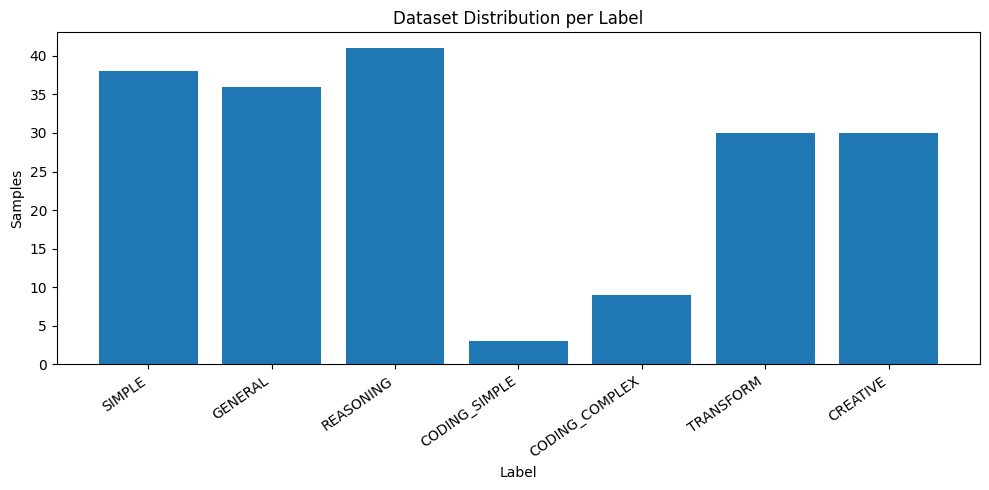


REAL PROMPT TEST

PROMPT:
berapa 15 persen dari 500
ROUTE: REASONING
CONFIDENCE: 0.234

PROMPT:
jelaskan fungsi docker compose
ROUTE: TRANSFORM
CONFIDENCE: 0.219

PROMPT:
bandingkan REST dan GraphQL untuk backend aplikasi besar
ROUTE: REASONING
CONFIDENCE: 0.28

PROMPT:
buat regex untuk validasi email
ROUTE: TRANSFORM
CONFIDENCE: 0.301

PROMPT:
buat function python untuk parsing json
ROUTE: TRANSFORM
CONFIDENCE: 0.233

PROMPT:
debug kenapa service systemd restart terus dan cari kemungkinan race condition
ROUTE: CODING_COMPLEX
CONFIDENCE: 0.409

PROMPT:
ringkas tulisan ini menjadi lima poin
ROUTE: SIMPLE
CONFIDENCE: 0.306

PROMPT:
terjemahkan kalimat ini ke bahasa Jepang
ROUTE: TRANSFORM
CONFIDENCE: 0.386

PROMPT:
buat cerita pendek tentang robot kecil
ROUTE: CREATIVE
CONFIDENCE: 0.427

PROMPT:
kenapa request API direct cepat tapi lewat router jadi lambat
ROUTE: REASONING
CONFIDENCE: 0.288

PROMPT:
review architecture backend saya, analisis bottleneck, retry strategy, dan desain ulang 

,prompt,route,confidence
0,berapa 15 persen dari 500,REASONING,0.233574
1,jelaskan fungsi docker compose,TRANSFORM,0.219095
2,bandingkan REST dan GraphQL untuk backend apli...,REASONING,0.280145
3,buat regex untuk validasi email,TRANSFORM,0.301113
4,buat function python untuk parsing json,TRANSFORM,0.233497
5,debug kenapa service systemd restart terus dan...,CODING_COMPLEX,0.409392
6,ringkas tulisan ini menjadi lima poin,SIMPLE,0.305594
7,terjemahkan kalimat ini ke bahasa Jepang,TRANSFORM,0.386211
8,buat cerita pendek tentang robot kecil,CREATIVE,0.426856
9,kenapa request API direct cepat tapi lewat rou...,REASONING,0.287921


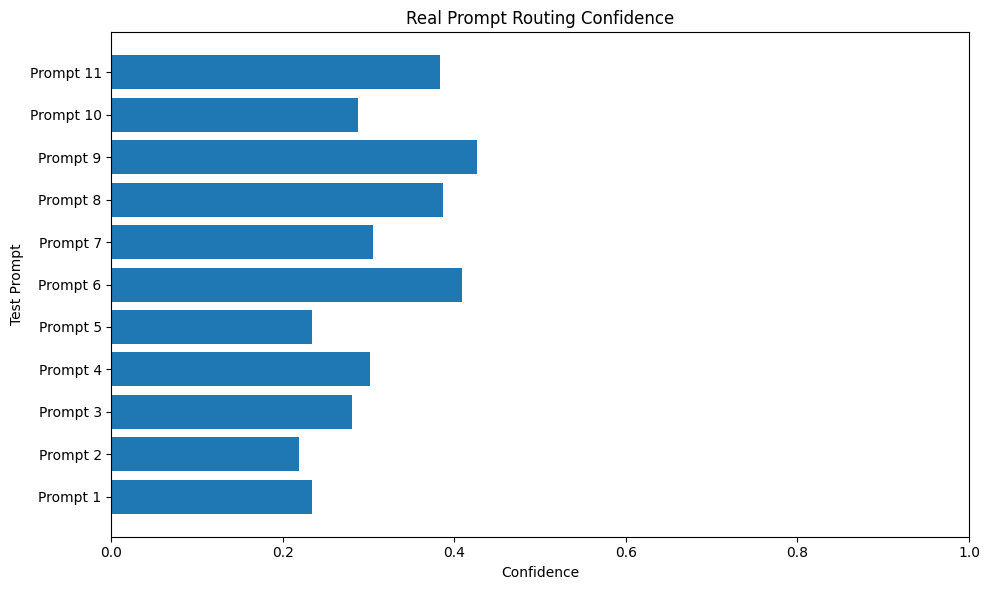

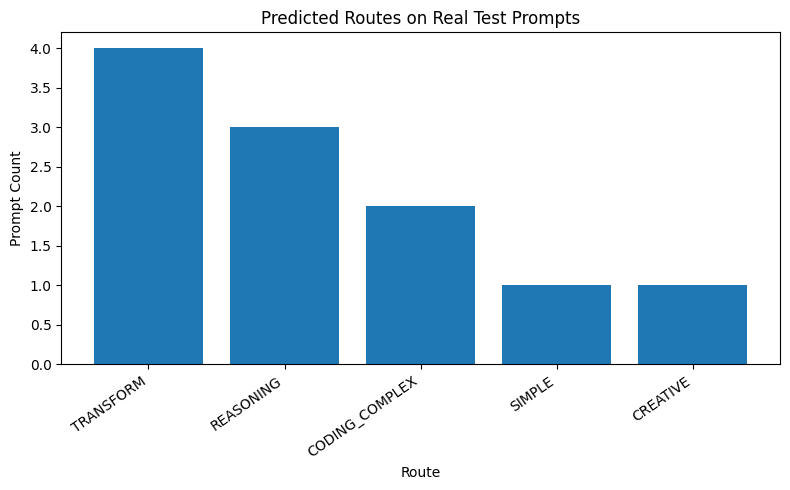

In [95]:
# =========================================================
# CHECK + VISUALIZE LAST ROUND
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ---------------------------------------------------------
# 1. PRINT METRICS
# ---------------------------------------------------------

print("=" * 60)
print("LAST ROUND METRICS")
print("=" * 60)

if metrics_current is not None:

    print(
        "Accuracy:",
        round(metrics_current["accuracy"], 3)
    )

    print(
        "Macro F1:",
        round(metrics_current["macro_f1"], 3)
    )

    print(
        "Test samples:",
        metrics_current["test_samples"]
    )

else:
    print("Metrics belum tersedia.")


# ---------------------------------------------------------
# 2. DATASET DISTRIBUTION
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET DISTRIBUTION")
print("=" * 60)

label_counts = (
    df_balanced["label"]
    .value_counts()
    .reindex(LABELS, fill_value=0)
)

print(label_counts)


# ---------------------------------------------------------
# 3. PLOT LABEL DISTRIBUTION
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    label_counts.index,
    label_counts.values
)

plt.title("Dataset Distribution per Label")
plt.xlabel("Label")
plt.ylabel("Samples")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. TEST REAL PROMPTS
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("REAL PROMPT TEST")
print("=" * 60)

test_embeddings = embedding_model.encode(
    REAL_TEST_PROMPTS,
    normalize_embeddings=True
)

predictions = classifier_current.predict(
    test_embeddings
)

probabilities = classifier_current.predict_proba(
    test_embeddings
)

real_results = []

for prompt, label, probs in zip(
    REAL_TEST_PROMPTS,
    predictions,
    probabilities
):

    confidence = float(
        probs.max()
    )

    real_results.append({
        "prompt": prompt,
        "route": label,
        "confidence": confidence
    })

    print("\nPROMPT:")
    print(prompt)

    print(
        "ROUTE:",
        label
    )

    print(
        "CONFIDENCE:",
        round(confidence, 3)
    )


# ---------------------------------------------------------
# 5. DATAFRAME TEST RESULT
# ---------------------------------------------------------

df_real_test = pd.DataFrame(
    real_results
)

print("\n")
display(
    df_real_test
)


# ---------------------------------------------------------
# 6. CONFIDENCE CHART
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

positions = np.arange(
    len(df_real_test)
)

plt.barh(
    positions,
    df_real_test["confidence"]
)

plt.yticks(
    positions,
    [
        f"Prompt {i+1}"
        for i in range(
            len(df_real_test)
        )
    ]
)

plt.xlabel("Confidence")
plt.ylabel("Test Prompt")
plt.title("Real Prompt Routing Confidence")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 7. ROUTE DISTRIBUTION REAL TEST
# ---------------------------------------------------------

route_counts = (
    df_real_test["route"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    route_counts.index,
    route_counts.values
)

plt.title(
    "Predicted Routes on Real Test Prompts"
)

plt.xlabel("Route")
plt.ylabel("Prompt Count")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()